# Object Detection For Autonomous Driving

## Objective

The goal of this assignment is to fine-tune the YOLO object detection model on a subset of the KITTI dataset, widely used in autonomous driving research. The KITTI dataset provides annotated images for tasks like object detection, tracking, and segmentation, making it ideal for training models to detect objects such as cars, pedestrians, and cyclists.

By completing this assignment, you will gain hands-on experience in dataset preparation, annotation conversion, model training, and performance evaluation using metrics like mAP (mean Average Precision). Additionally, you will explore the trade-offs between speed and accuracy, crucial for real-time applications like autonomous driving.


## Introduction: Object Detection

Object detection is a fundamental task in computer vision that involves identifying and localizing objects within an image or video.

The main techniques for object detection include traditional methods like sliding window and region-based approaches, as well as modern deep learning-based methods such as YOLO (You Only Look Once), SSD (Single Shot MultiBox Detector), and Faster R-CNN. These techniques leverage convolutional neural networks (CNNs) to extract features and predict bounding boxes and class labels for objects in real-time or near real-time.

Widely used models for object detection include:
- **YOLO (You Only Look Once)**: Known for its speed and efficiency in real-time applications.
- **Faster R-CNN**: A two-stage detector that provides high accuracy but is slower compared to single-stage detectors.
- **SSD (Single Shot MultiBox Detector)**: Balances speed and accuracy, making it suitable for various applications.
- **RetinaNet**: Introduces the focal loss to address class imbalance in object detection.
- **EfficientDet**: A family of models that optimize both accuracy and efficiency using compound scaling.

In the context of autonomous vehicles, object detection plays a critical role in perceiving the environment, identifying obstacles, pedestrians, traffic signs, and other vehicles. This capability enables autonomous systems to make informed decisions, ensuring safety and efficiency in navigation and driving scenarios.

## YOLO

YOLO (You Only Look Once) is a state-of-the-art, real-time object detection system. Unlike traditional object detection methods that apply a classifier to different regions of an image, YOLO frames object detection as a single regression problem. It predicts bounding boxes and class probabilities directly from full images in one evaluation, making it extremely fast and efficient.

### Model

The YOLO model divides the input image into a grid, where each grid cell is responsible for predicting bounding boxes and their associated class probabilities. Key features of YOLO include:

- **Unified Architecture**: YOLO uses a single convolutional neural network (CNN) to predict multiple bounding boxes and class probabilities simultaneously.
- **Speed**: YOLO is optimized for real-time applications, capable of processing images at high frame rates.
- **Global Context**: By considering the entire image during training and inference, YOLO reduces false positives and improves detection accuracy.
- **Versions**: Over time, YOLO has evolved through multiple versions (e.g., YOLOv1 up to YOLOv11), each introducing architectural improvements, better loss functions, and enhanced performance.

YOLO is widely used in applications such as autonomous driving, surveillance, and robotics, where real-time object detection is critical.

For more details on YOLO, visit the [Ultralytics GitHub repository](https://github.com/ultralytics/ultralytics).

## Theory Questions


For the next questions, focus on the latest version of the model, YOLOv11

Briefly describe the architecture used in YOLOv11 and the different losses used during training.

ANS: There's three parts in the architecture of the YOLOv11, the backbone, the neck and the head. The backbone is a convolutional neural network that extracts features from the input image. It capture low-level and high-level informations. The neck use max-pooling operations to aggregate multi-scale information. The module helps for the detection of small objects. Finally, head module predicts the coordinates of the object's bounding box and class probabilities.

Different losses are used in YOLOv11. It's the combination of bounding box regression loss, objectness loss and classification loss. First one measures how well the predicted boxes match the ground truth boxes and uses IoU-based losses. Second one determines whether an object is present in a predicted box and is implemented using Binary Cross-Entropy (BCE). Third one measures how accurately the model predicts the class of detected objects and often uses Cross-Entropy or Binary Cross-Entropy for multi-label classification.

What are the metrics used to assess YOLO's performance for object detection?

ANS: mAP (mean average precision) is computed across multiple classes and IoU thresholds. It is the most common metrics for object detection tasks. Higher mAP values indicate better object localization and classification. Second metric is IoU (intersection over union). It measures the overlap between the predicted bounding box and the ground truth box. An IoU threshold is used to determine if a prediction is considered a true positive. Last metric is the FPS (frame per second). It measures the speed of the model, indicating how many frames the model can process per second. A higher FPS means faster inference.

## Code

In the next part of the assignment, you will load a YOLO model and fine-tune it on the provided subset of the KITTI dataset.
You will then visualize the training losses and evaluate the model by running inference to assess its performance.

In [1]:
!pip install ultralytics opencv-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.2 MB/s eta 0:00:00


In [2]:
import os, cv2, glob, random, shutil, requests, zipfile
from ultralytics import YOLO

import matplotlib.pyplot as plt
import pandas as pd
import os

%matplotlib inline

from IPython.display import Image, display
import glob

import yaml
import cv2
import matplotlib.pyplot as plt
import glob

import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# ---------------------------------------------
# STEP 1: Setup paths
# ---------------------------------------------
HOME = os.getcwd()
DATASET_PATH = os.path.join(HOME, "datasets", "kitti_subset")
IMAGES_PATH = os.path.join(DATASET_PATH, "images")
LABELS_PATH = os.path.join(DATASET_PATH, "labels")

TRAIN_IMG = os.path.join(IMAGES_PATH, "train")
VAL_IMG = os.path.join(IMAGES_PATH, "val")
TEST_IMG = os.path.join(IMAGES_PATH, "test")
TRAIN_LABEL = os.path.join(LABELS_PATH, "train")
VAL_LABEL = os.path.join(LABELS_PATH, "val")
TEST_LABEL = os.path.join(LABELS_PATH, "test")

for path in [TRAIN_IMG, VAL_IMG, TEST_IMG, TRAIN_LABEL, VAL_LABEL, TEST_LABEL]:
    os.makedirs(path, exist_ok=True)

# ---------------------------------------------
# STEP 2: Download and extract KITTI data
# ---------------------------------------------
KITTI_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip"
KITTI_LABELS_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip"

def download_and_extract(url, extract_to):
    zip_path = os.path.join(HOME, url.split("/")[-1])
    if not os.path.exists(zip_path):
        print(f"Downloading {url}...")
        response = requests.get(url, stream=True)
        with open(zip_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file.write(chunk)
        print("Download complete.")

    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction complete.")

download_and_extract(KITTI_URL, IMAGES_PATH)
download_and_extract(KITTI_LABELS_URL, LABELS_PATH)

# ---------------------------------------------
# STEP 3: Convert KITTI annotations to YOLO
# ---------------------------------------------
CLASS_MAP = {"Car": 0, "Pedestrian": 1, "Cyclist": 2}

def convert_kitti_to_yolo(kitti_label_path, yolo_label_path, image_path):
    with open(kitti_label_path, "r") as file:
        lines = file.readlines()

    img = cv2.imread(image_path)
    if img is None:
        return
    height, width, _ = img.shape

    with open(yolo_label_path, "w") as yolo_file:
        for line in lines:
            elements = line.split()
            class_name = elements[0]
            if class_name not in CLASS_MAP:
                continue  # Skip irrelevant classes

            class_id = CLASS_MAP[class_name]
            x1, y1, x2, y2 = map(float, elements[4:8])

            # Convert to YOLO format
            center_x = ((x1 + x2) / 2) / width
            center_y = ((y1 + y2) / 2) / height
            bbox_width = (x2 - x1) / width
            bbox_height = (y2 - y1) / height

            yolo_file.write(f"{class_id} {center_x:.6f} {center_y:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")

# ---------------------------------------------
# STEP 4: Prepare dataset (subset, split, convert)
# ---------------------------------------------
all_images = sorted(glob.glob(os.path.join(IMAGES_PATH, "training", "image_2", "*.png")))
all_labels = sorted(glob.glob(os.path.join(LABELS_PATH, "training", "label_2", "*.txt")))

paired_data = list(zip(all_images, all_labels))
random.seed(42)
random.shuffle(paired_data)

# Keep small subset (e.g., 300 images total)
subset_data = paired_data[:300]
train_size = int(0.8 * len(subset_data))
val_size = int(0.1 * len(subset_data))

train_data = subset_data[:train_size]
val_data = subset_data[train_size:train_size + val_size]
test_data = subset_data[train_size + val_size:]

def move_and_convert_files(data, img_dest, lbl_dest):
    for img_path, lbl_path in data:
        new_img_path = os.path.join(img_dest, os.path.basename(img_path))
        new_lbl_path = os.path.join(lbl_dest, os.path.basename(lbl_path))
        shutil.copy2(img_path, new_img_path)
        convert_kitti_to_yolo(lbl_path, new_lbl_path, new_img_path)

move_and_convert_files(train_data, TRAIN_IMG, TRAIN_LABEL)
move_and_convert_files(val_data, VAL_IMG, VAL_LABEL)
move_and_convert_files(test_data, TEST_IMG, TEST_LABEL)


# ---------------------------------------------
# STEP 5: Create data.yaml
# ---------------------------------------------
data_yaml = f"""
path: {DATASET_PATH}
train: images/train
val: images/val
test: images/test

nc: 3
names: ['Car', 'Pedestrian', 'Cyclist']
"""

with open(os.path.join(DATASET_PATH, "data.yaml"), "w") as f:
    f.write(data_yaml)



Download complete.
Extracting /content/data_object_image_2.zip...
Extraction complete.
Download complete.
Extracting /content/data_object_label_2.zip...
Extraction complete.


In [4]:
# ---------------------------------------------
# STEP 6: Fine-tune YOLOv11 model
# ---------------------------------------------
#TO-DO: Add the code to fine-tune the YOLOv11 model

DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")
OUTPUT_DIR = os.path.join(HOME, "runs", "train_yolov11_finetune")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Hyperparams
MODEL_PRETRAIN = "yolo11m.pt"
EPOCHS = 50
BATCH = 16
IMG_SZ = 640
LR = 1e-3

# Create model object (loads pretrained weights)
model = YOLO(MODEL_PRETRAIN)

# Train / fine-tune
# key args: data (yaml), epochs, imgsz, batch, lr, project/name to control output dir, exist_ok to overwrite
model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SZ,
    batch=BATCH,
    lr0=LR,
    project=OUTPUT_DIR,
    name="finetune",
    exist_ok=True,
    device=0 if torch.cuda.is_available() else "cpu",
    save=True,               # save checkpoints
    save_period=1,           # save every epoch
    patience=50,             # early stopping patience
    verbose=True
)

# After training: best weights path
best_weights = os.path.join(OUTPUT_DIR, "finetune", "weights", "best.pt")
print("Best weights saved at:", best_weights)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/kitti_subset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

# Inference

After training, visualize the losses andmetrics calculated on the validation set during training.

Additionally, make sure you visualize the confusion matrix to see per-class errors.

For qualitative analysis, run inference on the model, visualise the bouding boxes and visually assess it.

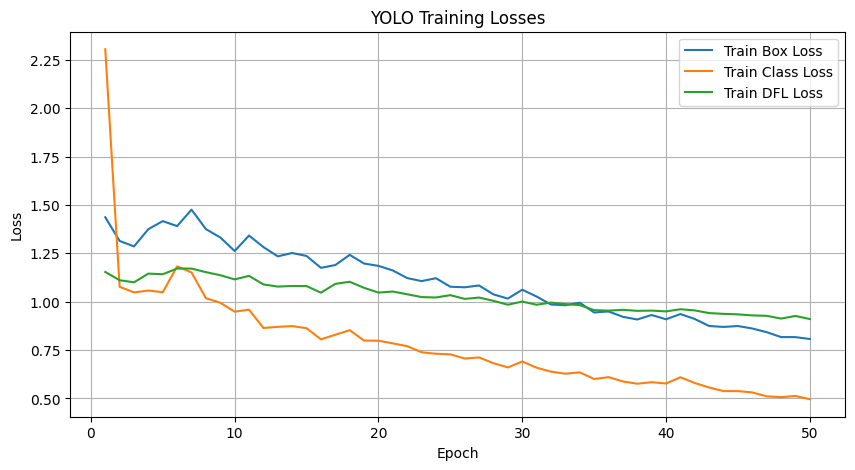

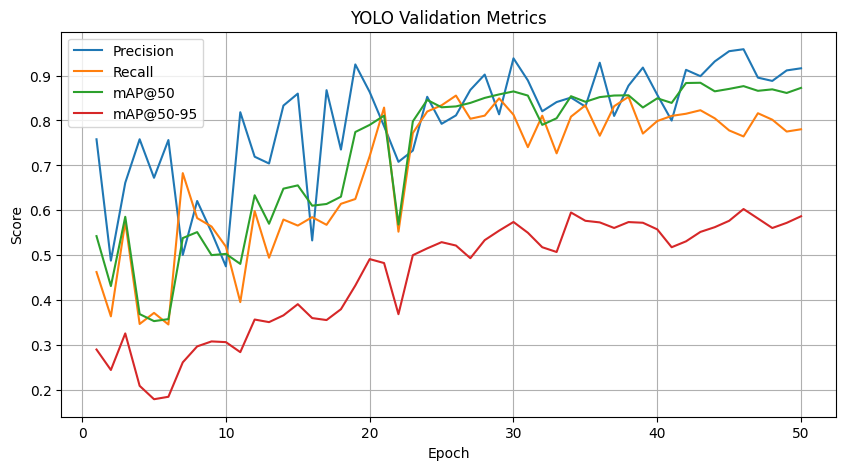

In [5]:
# -------- VISUALIZE TRAINING LOSSES AND METRICS --------
#TO-DO: Add the code to visualize the training losses and metrics

# Path to results.csv
results_path = os.path.join(OUTPUT_DIR, "finetune", "results.csv")

# Load results
df = pd.read_csv(results_path)

# -------------------------------
# Plot Losses
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss')
plt.plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('YOLO Training Losses')
plt.legend()
plt.grid()
plt.show()

# -------------------------------
# Plot Metrics
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95')

plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('YOLO Validation Metrics')
plt.legend()
plt.grid()
plt.show()

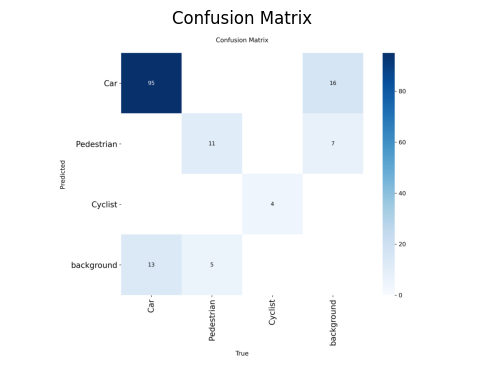

In [6]:
# ------ VISUALIZE CONFUSION MATRIX --------
#TO-DO: Add the code to visualize the confusion matrix
import matplotlib.image as mpimg

cm_path = os.path.join(OUTPUT_DIR, "finetune", "confusion_matrix.png")

img = mpimg.imread(cm_path)
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title("Confusion Matrix")
plt.show()


image 1/1 /content/datasets/kitti_subset/images/test/006301.png: 224x640 6 Cars, 76.5ms
Speed: 1.3ms preprocess, 76.5ms inference, 3.3ms postprocess per image at shape (1, 3, 224, 640)

image 1/1 /content/datasets/kitti_subset/images/test/002731.png: 224x640 12 Cars, 22.2ms
Speed: 1.9ms preprocess, 22.2ms inference, 2.3ms postprocess per image at shape (1, 3, 224, 640)

image 1/1 /content/datasets/kitti_subset/images/test/003814.png: 224x640 2 Cars, 23.3ms
Speed: 2.0ms preprocess, 23.3ms inference, 2.1ms postprocess per image at shape (1, 3, 224, 640)

image 1/1 /content/datasets/kitti_subset/images/test/003446.png: 224x640 1 Car, 46.8ms
Speed: 5.8ms preprocess, 46.8ms inference, 4.0ms postprocess per image at shape (1, 3, 224, 640)

image 1/1 /content/datasets/kitti_subset/images/test/005355.png: 224x640 1 Car, 25.7ms
Speed: 1.8ms preprocess, 25.7ms inference, 2.2ms postprocess per image at shape (1, 3, 224, 640)


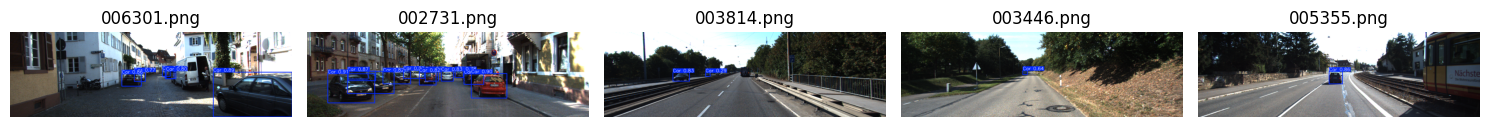

In [7]:
# -------- RUN INFERENCE AND PLOT SAMPLE OUTPUTS --------
#TO-DO: Add the code to run inference and visualize the outputs results

# Load trained model
best_weights = os.path.join(OUTPUT_DIR, "finetune", "weights", "best.pt")
model = YOLO(best_weights)

# Select test images
test_images = sorted(os.listdir(TEST_IMG))
sample_images = random.sample(test_images, min(5, len(test_images)))

plt.figure(figsize=(15, 8))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(TEST_IMG, img_name)

    # Run inference on single image
    results = model.predict(
        source=img_path,
        imgsz=IMG_SZ,
        conf=0.25,
        device=0 if torch.cuda.is_available() else "cpu",
        save=False
    )

    # Get plotted image (with boxes)
    img_with_boxes = results[0].plot()

    # Convert BGR → RGB (important for matplotlib)
    img_with_boxes = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)

    # Plot
    plt.subplot(1, len(sample_images), i+1)
    plt.imshow(img_with_boxes)
    plt.title(img_name[:10])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Question

Comment on the performance of the model based on the visualizations you made and discuss the inference speed versus performance for YOLO on the driving datasets. Do you think we can use YOLO online on autonomous cars?

## Ans

The training loss curves show that the model is learning effectively, as all losses (box, classification, and DFL) decrease over epochs, indicating convergence. The classification loss drops quickly, suggesting the model learns to distinguish object classes early, while the box and DFL losses decrease more gradually, reflecting progressive improvement in localization accuracy. Regarding inference speed versus performance, YOLO provides an excellent trade-off for driving datasets: each image take approximatly 20ms to process and produce an output (50 FPS) while maintaining good detection accuracy (0.9 precision) for important objects such as cars, pedestrians, and cyclists. However, this speed comes at a slight cost in precision compared to slower, more complex models, especially for small or distant objects. Therefore, YOLO is well-suited for real-time applications like autonomous driving, but it is typically used as part of a larger system alongside tracking, sensor fusion (e.g., LiDAR), and other models to ensure robustness and safety.